# Phase 1 — CIFAR-10 Centralized Baseline

In [1]:
# ============================================================
# CELL 1 — Imports & Setup
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [2]:
# ============================================================
# CELL 2 — Data loading, normalization, DataLoaders
# ============================================================
# Standard CIFAR-10 per-channel mean/std (widely used, precomputed constants)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # light augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_set = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data", train=True, download=True, transform=transform_train
)
test_set = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data", train=False, download=True, transform=transform_test
)

BATCH_SIZE = 128

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")
classes = train_set.classes
print("Classes:", classes)

100%|██████████| 170M/170M [00:19<00:00, 8.97MB/s]


Train samples: 50000, Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# ============================================================
# CELL 3 — Simple CNN
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16x16 -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Model parameters: 1,116,970


In [4]:
# ============================================================
# CELL 4 — Loss, optimizer, training loop
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [5]:
# ============================================================
# CELL 5 — Run training
# ============================================================
NUM_EPOCHS = 15

history = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [],
}

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time:.1f}s ({total_time/NUM_EPOCHS:.1f}s/epoch)")

Epoch  1/15 | Train Loss: 1.9606 Acc: 0.2709 | Test Loss: 1.5745 Acc: 0.4134
Epoch  2/15 | Train Loss: 1.5305 Acc: 0.4393 | Test Loss: 1.2733 Acc: 0.5442
Epoch  3/15 | Train Loss: 1.3339 Acc: 0.5145 | Test Loss: 1.1311 Acc: 0.5995
Epoch  4/15 | Train Loss: 1.1723 Acc: 0.5768 | Test Loss: 1.0200 Acc: 0.6332
Epoch  5/15 | Train Loss: 1.0612 Acc: 0.6225 | Test Loss: 0.9461 Acc: 0.6674
Epoch  6/15 | Train Loss: 0.9748 Acc: 0.6548 | Test Loss: 0.8649 Acc: 0.6960
Epoch  7/15 | Train Loss: 0.9238 Acc: 0.6728 | Test Loss: 0.8326 Acc: 0.7061
Epoch  8/15 | Train Loss: 0.8695 Acc: 0.6950 | Test Loss: 0.7811 Acc: 0.7286
Epoch  9/15 | Train Loss: 0.8180 Acc: 0.7105 | Test Loss: 0.7365 Acc: 0.7455
Epoch 10/15 | Train Loss: 0.7872 Acc: 0.7235 | Test Loss: 0.7140 Acc: 0.7507
Epoch 11/15 | Train Loss: 0.7488 Acc: 0.7361 | Test Loss: 0.6806 Acc: 0.7618
Epoch 12/15 | Train Loss: 0.7239 Acc: 0.7476 | Test Loss: 0.6396 Acc: 0.7792
Epoch 13/15 | Train Loss: 0.6969 Acc: 0.7558 | Test Loss: 0.6350 Acc: 0.7772

In [6]:
# ============================================================
# CELL 6 — Save baseline results (for later comparison to FL)
# ============================================================
import json

baseline_results = {
    "history": history,
    "total_training_time_sec": total_time,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "final_test_acc": history["test_acc"][-1],
}

with open("/kaggle/working/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

torch.save(model.state_dict(), "/kaggle/working/baseline_model.pt")

print("Saved baseline_results.json and baseline_model.pt")

Saved baseline_results.json and baseline_model.pt


# Phase 2 — Federated Learning (FedAvg, 5 clients, IID)

The FedAvg algorithm itself follows the original paper: McMahan et al., "Communication-Efficient Learning of Deep Networks from Decentralized Data," AISTATS 2017 (arXiv:1602.05629)

In [7]:
# ============================================================
# CELL 1 — Imports & multi-GPU setup
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import copy
import time
import json

torch.manual_seed(42)
np.random.seed(42)

NUM_GPUS = torch.cuda.device_count()
print(f"Available GPUs: {NUM_GPUS}")
devices = [torch.device(f"cuda:{i}") for i in range(NUM_GPUS)] if NUM_GPUS > 0 else [torch.device("cpu")]
print("Using devices:", devices)

def get_device_for_client(client_id):
    """Round-robin assignment of clients to available GPUs."""
    return devices[client_id % len(devices)]

Available GPUs: 2
Using devices: [device(type='cuda', index=0), device(type='cuda', index=1)]


In [8]:
# ============================================================
# CELL 2 — Data loading (same normalization as Phase 1)
# ============================================================
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

# NOTE: for FL, we drop train-time augmentation (RandomCrop/Flip) that Phase 1 used.
# Reason: with augmentation, two clients holding the "same" underlying image could
# still diverge in ways unrelated to federation, muddying the IID vs non-IID comparison
# in Phase 3. We keep normalization only, consistently across phases.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_set = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="/kaggle/working/data", train=False, download=True, transform=transform
)

test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

In [9]:
# ============================================================
# CELL 3 — IID client partitioning
# ============================================================
NUM_CLIENTS = 5

def iid_partition(dataset, num_clients, seed=42):
    """Shuffle indices and split evenly across clients — standard IID split."""
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)
    splits = np.array_split(indices, num_clients)
    return [split.tolist() for split in splits]

client_indices = iid_partition(train_set, NUM_CLIENTS)

for i, idxs in enumerate(client_indices):
    print(f"Client {i}: {len(idxs)} samples")

client_datasets = [Subset(train_set, idxs) for idxs in client_indices]
client_loaders = [
    DataLoader(ds, batch_size=64, shuffle=True, num_workers=2)
    for ds in client_datasets
]

Client 0: 10000 samples
Client 1: 10000 samples
Client 2: 10000 samples
Client 3: 10000 samples
Client 4: 10000 samples


In [10]:
# ============================================================
# CELL 4 — Model (identical architecture to Phase 1)
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
# ============================================================
# CELL 5 — Client-side local training
# ============================================================
def local_train(global_state_dict, client_loader, device, local_epochs=1, lr=0.01):
    """
    Client receives the global model, trains locally, returns its updated
    state_dict (parameters) — NOT gradients. This is standard FedAvg: the
    server aggregates model weights directly (McMahan et al. 2017).
    """
    model = SimpleCNN().to(device)
    model.load_state_dict(global_state_dict)
    model.train()

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(local_epochs):
        for images, labels in client_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Move state dict to CPU before returning, to avoid holding GPU memory
    # for every client's model simultaneously and to simplify aggregation.
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

In [12]:
# ============================================================
# CELL 6 — FedAvg aggregation
# ============================================================
def fedavg_aggregate(client_state_dicts, client_num_samples):
    """
    Weighted average of client parameters, weighted by each client's number
    of local samples — this is the FedAvg rule from McMahan et al. 2017,
    Algorithm 1 (Section 3), NOT a simple unweighted average.
    """
    total_samples = sum(client_num_samples)
    avg_state_dict = copy.deepcopy(client_state_dicts[0])

    for key in avg_state_dict.keys():
        avg_state_dict[key] = torch.zeros_like(avg_state_dict[key], dtype=torch.float32)

    for state_dict, num_samples in zip(client_state_dicts, client_num_samples):
        weight = num_samples / total_samples
        for key in avg_state_dict.keys():
            avg_state_dict[key] += state_dict[key].float() * weight

    return avg_state_dict

In [13]:
# ============================================================
# CELL 7 — Global evaluation
# ============================================================
def evaluate_global(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [14]:
# ============================================================
# CELL 8 — Federated training loop (with concurrent multi-GPU clients)
# ============================================================
import concurrent.futures

NUM_ROUNDS = 30
LOCAL_EPOCHS = 1
LR = 0.01

global_model = SimpleCNN()
global_state_dict = {k: v.cpu().clone() for k, v in global_model.state_dict().items()}

eval_device = devices[0]
eval_model = SimpleCNN().to(eval_device)

fl_history = {"round": [], "test_loss": [], "test_acc": []}
client_num_samples = [len(idxs) for idxs in client_indices]

start_time = time.time()

for rnd in range(1, NUM_ROUNDS + 1):
    client_updates = [None] * NUM_CLIENTS

    # Run clients concurrently, round-robined across available GPUs.
    with concurrent.futures.ThreadPoolExecutor(max_workers=len(devices)) as executor:
        futures = {}
        for cid in range(NUM_CLIENTS):
            dev = get_device_for_client(cid)
            fut = executor.submit(
                local_train, global_state_dict, client_loaders[cid], dev, LOCAL_EPOCHS, LR
            )
            futures[fut] = cid
        for fut in concurrent.futures.as_completed(futures):
            cid = futures[fut]
            client_updates[cid] = fut.result()

    # Server-side aggregation
    global_state_dict = fedavg_aggregate(client_updates, client_num_samples)

    # Evaluate global model
    eval_model.load_state_dict(global_state_dict)
    test_loss, test_acc = evaluate_global(eval_model, test_loader, eval_device)

    fl_history["round"].append(rnd)
    fl_history["test_loss"].append(test_loss)
    fl_history["test_acc"].append(test_acc)

    print(f"Round {rnd:2d}/{NUM_ROUNDS} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTotal FL training time: {total_time:.1f}s ({total_time/NUM_ROUNDS:.1f}s/round)")

Round  1/30 | Test Loss: 1.9254 | Test Acc: 0.3272
Round  2/30 | Test Loss: 1.5535 | Test Acc: 0.4422
Round  3/30 | Test Loss: 1.3796 | Test Acc: 0.4948
Round  4/30 | Test Loss: 1.2735 | Test Acc: 0.5444
Round  5/30 | Test Loss: 1.1885 | Test Acc: 0.5782
Round  6/30 | Test Loss: 1.0903 | Test Acc: 0.6122
Round  7/30 | Test Loss: 1.0323 | Test Acc: 0.6342
Round  8/30 | Test Loss: 0.9663 | Test Acc: 0.6577
Round  9/30 | Test Loss: 0.9146 | Test Acc: 0.6792
Round 10/30 | Test Loss: 0.8732 | Test Acc: 0.6971
Round 11/30 | Test Loss: 0.8473 | Test Acc: 0.7087
Round 12/30 | Test Loss: 0.8140 | Test Acc: 0.7225
Round 13/30 | Test Loss: 0.7804 | Test Acc: 0.7318
Round 14/30 | Test Loss: 0.7588 | Test Acc: 0.7377
Round 15/30 | Test Loss: 0.7461 | Test Acc: 0.7426
Round 16/30 | Test Loss: 0.7210 | Test Acc: 0.7527
Round 17/30 | Test Loss: 0.7119 | Test Acc: 0.7583
Round 18/30 | Test Loss: 0.6977 | Test Acc: 0.7619
Round 19/30 | Test Loss: 0.6903 | Test Acc: 0.7660
Round 20/30 | Test Loss: 0.6939

In [15]:
# ============================================================
# CELL 9 — Save results
# ============================================================
fl_results = {
    "history": fl_history,
    "num_clients": NUM_CLIENTS,
    "num_rounds": NUM_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "partition": "IID",
    "total_time_sec": total_time,
    "final_test_acc": fl_history["test_acc"][-1],
}

with open("/kaggle/working/fl_iid_results.json", "w") as f:
    json.dump(fl_results, f, indent=2)

torch.save(global_state_dict, "/kaggle/working/fl_iid_global_model.pt")
print("Saved fl_iid_results.json and fl_iid_global_model.pt")

Saved fl_iid_results.json and fl_iid_global_model.pt


# Phase 3 — IID vs Non-IID Partitioning

For non-IID, I'll implement the Dirichlet label-skew partition, which is the most widely used non-IID benchmark in FL literature — used in Hsu, Qi & Brown, "Measuring the Effects of Non-Identical Data Distribution for Federated Visual Classification," 2019 (arXiv:1909.06335), and adopted as a standard baseline in many later FL papers (including DP-FL work)

In [16]:
# ============================================================
# CELL 1 — Non-IID (Dirichlet label-skew) partitioning
# ============================================================
# Method: Hsu, Qi & Brown, "Measuring the Effects of Non-Identical Data
# Distribution for Federated Visual Classification" (2019, arXiv:1909.06335).
# Each client's class proportions are drawn from a Dirichlet distribution
# with concentration parameter alpha. Small alpha -> more skewed (more non-IID);
# large alpha -> approaches IID.

def dirichlet_partition(dataset, num_clients, alpha=0.5, seed=42):
    rng = np.random.default_rng(seed)
    labels = np.array(dataset.targets)
    num_classes = len(np.unique(labels))

    class_indices = [np.where(labels == c)[0] for c in range(num_classes)]
    for idxs in class_indices:
        rng.shuffle(idxs)

    client_indices = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        class_size = len(class_indices[c])
        # Sample a proportion of this class's data for each client
        proportions = rng.dirichlet(alpha=[alpha] * num_clients)
        # Convert proportions to actual split points
        split_points = (np.cumsum(proportions) * class_size).astype(int)[:-1]
        splits = np.split(class_indices[c], split_points)
        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())

    for idxs in client_indices:
        rng.shuffle(idxs)

    return client_indices

ALPHA = 0.5  # moderate skew — a common default in the literature (e.g. alpha=0.5, 0.1 are typical test points)

noniid_client_indices = dirichlet_partition(train_set, NUM_CLIENTS, alpha=ALPHA)

for i, idxs in enumerate(noniid_client_indices):
    label_counts = np.bincount(np.array(train_set.targets)[idxs], minlength=10)
    print(f"Client {i}: {len(idxs)} samples | class distribution: {label_counts}")

Client 0: 20313 samples | class distribution: [2761 2751 2479 2825  125  949   22 2549 3360 2492]
Client 1: 10012 samples | class distribution: [ 869  112   81  912 2223 2531 1391 1148  455  290]
Client 2: 3665 samples | class distribution: [ 884  131  353  103  230  493  378   35 1019   39]
Client 3: 7296 samples | class distribution: [  81  657  614  233    9  775 3191  936  165  635]
Client 4: 8714 samples | class distribution: [ 405 1349 1473  927 2413  252   18  332    1 1544]


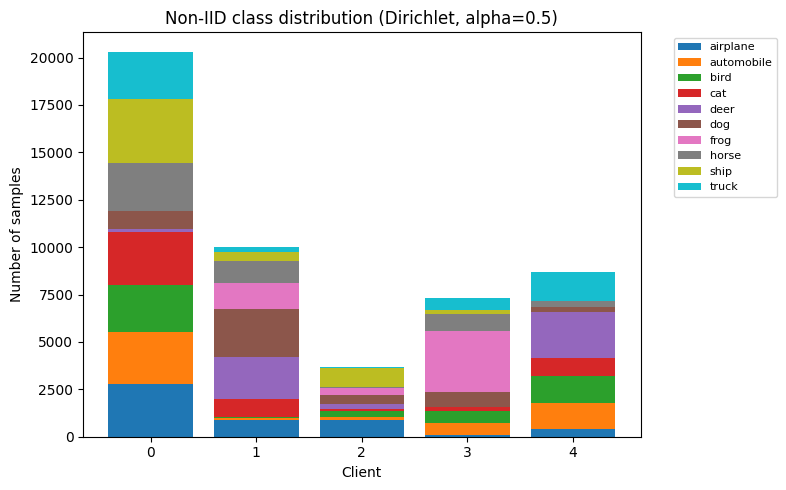

In [17]:
# ============================================================
# CELL 2 — Visualize the skew (sanity check you can see, not just numbers)
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
class_dist_matrix = np.array([
    np.bincount(np.array(train_set.targets)[idxs], minlength=10)
    for idxs in noniid_client_indices
])

bottom = np.zeros(NUM_CLIENTS)
for c in range(10):
    ax.bar(range(NUM_CLIENTS), class_dist_matrix[:, c], bottom=bottom, label=train_set.classes[c])
    bottom += class_dist_matrix[:, c]

ax.set_xlabel("Client")
ax.set_ylabel("Number of samples")
ax.set_title(f"Non-IID class distribution (Dirichlet, alpha={ALPHA})")
ax.set_xticks(range(NUM_CLIENTS))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/noniid_distribution.png", dpi=120)
plt.show()

In [18]:
# ============================================================
# CELL 3 — Build non-IID DataLoaders
# ============================================================
noniid_client_datasets = [Subset(train_set, idxs) for idxs in noniid_client_indices]
noniid_client_loaders = [
    DataLoader(ds, batch_size=64, shuffle=True, num_workers=2)
    for ds in noniid_client_datasets
]

noniid_client_num_samples = [len(idxs) for idxs in noniid_client_indices]

In [19]:
# ============================================================
# CELL 4 — Run FL training on non-IID split
# (Reuses local_train, fedavg_aggregate, evaluate_global from Phase 2 — unchanged)
# ============================================================
NUM_ROUNDS = 30
LOCAL_EPOCHS = 1
LR = 0.01

global_model = SimpleCNN()
global_state_dict = {k: v.cpu().clone() for k, v in global_model.state_dict().items()}
eval_model = SimpleCNN().to(eval_device)

noniid_history = {"round": [], "test_loss": [], "test_acc": []}

start_time = time.time()

for rnd in range(1, NUM_ROUNDS + 1):
    client_updates = [None] * NUM_CLIENTS

    with concurrent.futures.ThreadPoolExecutor(max_workers=len(devices)) as executor:
        futures = {}
        for cid in range(NUM_CLIENTS):
            dev = get_device_for_client(cid)
            fut = executor.submit(
                local_train, global_state_dict, noniid_client_loaders[cid], dev, LOCAL_EPOCHS, LR
            )
            futures[fut] = cid
        for fut in concurrent.futures.as_completed(futures):
            cid = futures[fut]
            client_updates[cid] = fut.result()

    global_state_dict = fedavg_aggregate(client_updates, noniid_client_num_samples)

    eval_model.load_state_dict(global_state_dict)
    test_loss, test_acc = evaluate_global(eval_model, test_loader, eval_device)

    noniid_history["round"].append(rnd)
    noniid_history["test_loss"].append(test_loss)
    noniid_history["test_acc"].append(test_acc)

    print(f"Round {rnd:2d}/{NUM_ROUNDS} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

noniid_total_time = time.time() - start_time
print(f"\nTotal non-IID FL training time: {noniid_total_time:.1f}s ({noniid_total_time/NUM_ROUNDS:.1f}s/round)")

Round  1/30 | Test Loss: 2.1087 | Test Acc: 0.2824
Round  2/30 | Test Loss: 1.5945 | Test Acc: 0.4238
Round  3/30 | Test Loss: 1.4262 | Test Acc: 0.4752
Round  4/30 | Test Loss: 1.3181 | Test Acc: 0.5247
Round  5/30 | Test Loss: 1.1844 | Test Acc: 0.5733
Round  6/30 | Test Loss: 1.0769 | Test Acc: 0.6138
Round  7/30 | Test Loss: 1.0433 | Test Acc: 0.6296
Round  8/30 | Test Loss: 0.9727 | Test Acc: 0.6533
Round  9/30 | Test Loss: 0.9280 | Test Acc: 0.6667
Round 10/30 | Test Loss: 0.9216 | Test Acc: 0.6723
Round 11/30 | Test Loss: 0.8976 | Test Acc: 0.6843
Round 12/30 | Test Loss: 0.8283 | Test Acc: 0.7113
Round 13/30 | Test Loss: 0.8314 | Test Acc: 0.7084
Round 14/30 | Test Loss: 0.8222 | Test Acc: 0.7136
Round 15/30 | Test Loss: 0.8000 | Test Acc: 0.7208
Round 16/30 | Test Loss: 0.7912 | Test Acc: 0.7255
Round 17/30 | Test Loss: 0.8061 | Test Acc: 0.7231
Round 18/30 | Test Loss: 0.7841 | Test Acc: 0.7275
Round 19/30 | Test Loss: 0.7753 | Test Acc: 0.7372
Round 20/30 | Test Loss: 0.8074

In [20]:
# ============================================================
# CELL 5 — Save non-IID results
# ============================================================
noniid_results = {
    "history": noniid_history,
    "num_clients": NUM_CLIENTS,
    "num_rounds": NUM_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "partition": "non-IID (Dirichlet)",
    "dirichlet_alpha": ALPHA,
    "total_time_sec": noniid_total_time,
    "final_test_acc": noniid_history["test_acc"][-1],
}

with open("/kaggle/working/fl_noniid_results.json", "w") as f:
    json.dump(noniid_results, f, indent=2)

torch.save(global_state_dict, "/kaggle/working/fl_noniid_global_model.pt")
print("Saved fl_noniid_results.json and fl_noniid_global_model.pt")

Saved fl_noniid_results.json and fl_noniid_global_model.pt


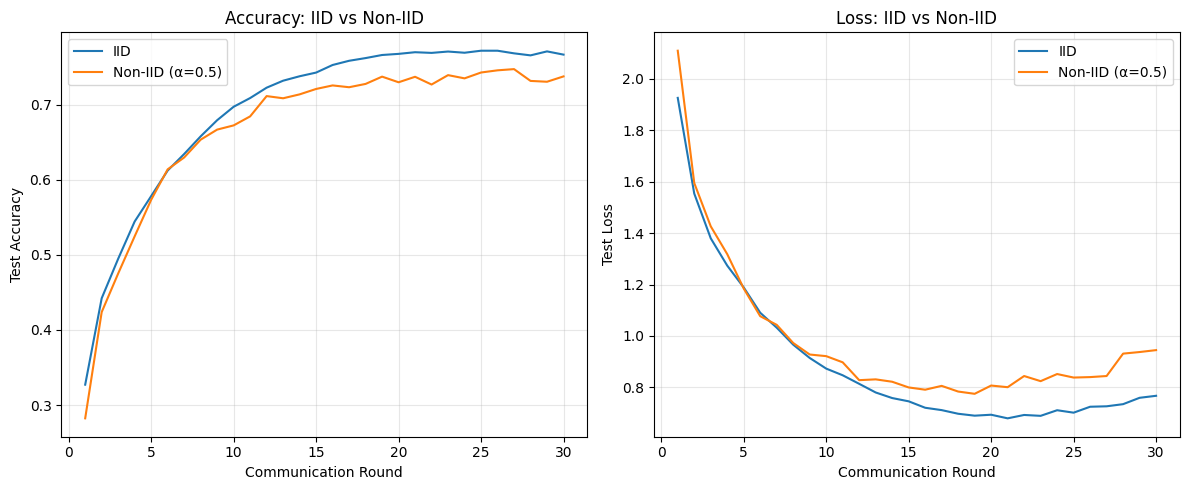

In [21]:
# ============================================================
# CELL 6 — Direct comparison plot: IID vs Non-IID
# ============================================================
with open("/kaggle/working/fl_iid_results.json") as f:
    iid_results = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(iid_results["history"]["round"], iid_results["history"]["test_acc"], label="IID")
axes[0].plot(noniid_results["history"]["round"], noniid_results["history"]["test_acc"], label=f"Non-IID (α={ALPHA})")
axes[0].set_xlabel("Communication Round")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Accuracy: IID vs Non-IID")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(iid_results["history"]["round"], iid_results["history"]["test_loss"], label="IID")
axes[1].plot(noniid_results["history"]["round"], noniid_results["history"]["test_loss"], label=f"Non-IID (α={ALPHA})")
axes[1].set_xlabel("Communication Round")
axes[1].set_ylabel("Test Loss")
axes[1].set_title("Loss: IID vs Non-IID")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/iid_vs_noniid_comparison.png", dpi=120)
plt.show()

# Phase 4 — Adding Differential Privacy

Opacus implements the DP-SGD algorithm from Abadi et al., "Deep Learning with Differential Privacy," CCS 2016 (arXiv:1607.00133), which is the foundational DP-SGD paper

In [22]:
# ============================================================
# CELL — Updated SimpleCNN, Opacus-compatible (no in-place ops)
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),                     # inplace=False (default)
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [23]:
# ============================================================
# CELL 1 — Install & import Opacus
# ============================================================
!pip install -q opacus

import torch
import torch.nn as nn
import torch.optim as optim
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import copy

# Opacus requires per-sample-gradient-friendly modules. Our SimpleCNN from
# Phase 1/2 uses no BatchNorm, so it should already be compatible — but we
# validate explicitly rather than assume.
errors = ModuleValidator.validate(SimpleCNN(), strict=False)
print("Opacus validation errors:", errors if errors else "None — model is compatible")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 16.8 MB/s eta 0:00:00
Opacus validation errors: None — model is compatible


In [24]:
# ============================================================
# CELL — Persistent per-client DP state (models, optimizers, engines)
# Replaces the old "fresh PrivacyEngine every round" approach.
# ============================================================
from opacus import PrivacyEngine

NOISE_MULTIPLIER = 1.0
MAX_GRAD_NORM = 1.0
DELTA = 1e-5
LR = 0.01

client_models = []
client_optimizers = []
client_privacy_engines = []
client_loaders_dp = []  # Opacus wraps the loader too; keep the wrapped version

for cid in range(NUM_CLIENTS):
    dev = get_device_for_client(cid)

    model = SimpleCNN().to(dev)
    model.load_state_dict(global_state_dict)  # start from current global weights

    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)

    privacy_engine = PrivacyEngine()
    model, optimizer, loader_dp = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=client_loaders[cid],
        noise_multiplier=NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    client_models.append(model)
    client_optimizers.append(optimizer)
    client_privacy_engines.append(privacy_engine)
    client_loaders_dp.append(loader_dp)

print(f"Initialized {NUM_CLIENTS} persistent DP-wrapped clients.")

Initialized 5 persistent DP-wrapped clients.


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [25]:
# ============================================================
# CELL — DP local training step using a PERSISTENT client (accumulates ε)
# ============================================================
def local_train_dp_persistent(model, optimizer, loader_dp, global_state_dict,
                                device, local_epochs=1):
    """
    Loads current global weights into the client's PERSISTENT DP-wrapped
    model (so the PrivacyEngine's internal step/accountant state carries
    over from previous rounds), trains locally, and returns updated weights.
    Does NOT create a new PrivacyEngine -> epsilon accumulates correctly
    across the calling loop's rounds.
    """
    # Load global weights into the wrapped module (note the _module. prefix
    # Opacus's GradSampleModule adds internally).
    with torch.no_grad():
        wrapped_state = model.state_dict()
        for k, v in global_state_dict.items():
            wrapped_key = f"_module.{k}"
            if wrapped_key in wrapped_state:
                wrapped_state[wrapped_key].copy_(v.to(device))

    model.train()
    criterion = nn.CrossEntropyLoss()

    for epoch in range(local_epochs):
        for images, labels in loader_dp:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    clean_state_dict = {
        k.replace("_module.", ""): v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    return clean_state_dict

In [26]:
# ============================================================
# CELL — Federated DP training loop with persistent, cumulative-ε clients
# ============================================================
NUM_ROUNDS = 30

dp_history = {"round": [], "test_loss": [], "test_acc": [], "client_epsilons": []}

start_time = time.time()

for rnd in range(1, NUM_ROUNDS + 1):
    client_updates = [None] * NUM_CLIENTS

    # NOTE: Opacus's per-client state (model, optimizer, privacy_engine) is
    # NOT thread-safe to share across threads touching different objects
    # simultaneously is fine (each client has its OWN model/optimizer/engine),
    # but to be safe and keep ε accounting deterministic, we run clients
    # concurrently by device as before — each client's own persistent
    # objects are only touched by its own thread.
    with concurrent.futures.ThreadPoolExecutor(max_workers=len(devices)) as executor:
        futures = {}
        for cid in range(NUM_CLIENTS):
            dev = get_device_for_client(cid)
            fut = executor.submit(
                local_train_dp_persistent,
                client_models[cid], client_optimizers[cid], client_loaders_dp[cid],
                global_state_dict, dev, LOCAL_EPOCHS
            )
            futures[fut] = cid
        for fut in concurrent.futures.as_completed(futures):
            cid = futures[fut]
            client_updates[cid] = fut.result()

    global_state_dict = fedavg_aggregate(client_updates, client_num_samples)

    eval_model.load_state_dict(global_state_dict)
    test_loss, test_acc = evaluate_global(eval_model, test_loader, eval_device)

    # Query CUMULATIVE epsilon from each client's persistent accountant —
    # this now correctly reflects privacy spent over ALL rounds so far.
    round_epsilons = [
        client_privacy_engines[cid].get_epsilon(delta=DELTA)
        for cid in range(NUM_CLIENTS)
    ]

    dp_history["round"].append(rnd)
    dp_history["test_loss"].append(test_loss)
    dp_history["test_acc"].append(test_acc)
    dp_history["client_epsilons"].append(round_epsilons)

    avg_eps = np.mean(round_epsilons)
    print(f"Round {rnd:2d}/{NUM_ROUNDS} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Cumulative avg client ε: {avg_eps:.3f}")

dp_total_time = time.time() - start_time
print(f"\nTotal DP-FL training time: {dp_total_time:.1f}s ({dp_total_time/NUM_ROUNDS:.1f}s/round)")

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Round  1/30 | Test Loss: 1.0717 | Test Acc: 0.7539 | Cumulative avg client ε: 0.532
Round  2/30 | Test Loss: 1.2244 | Test Acc: 0.7523 | Cumulative avg client ε: 0.687
Round  3/30 | Test Loss: 1.3870 | Test Acc: 0.7480 | Cumulative avg client ε: 0.810
Round  4/30 | Test Loss: 1.5109 | Test Acc: 0.7425 | Cumulative avg client ε: 0.917
Round  5/30 | Test Loss: 1.6203 | Test Acc: 0.7392 | Cumulative avg client ε: 1.013
Round  6/30 | Test Loss: 1.7338 | Test Acc: 0.7329 | Cumulative avg client ε: 1.101
Round  7/30 | Test Loss: 1.8185 | Test Acc: 0.7267 | Cumulative avg client ε: 1.184
Round  8/30 | Test Loss: 1.8973 | Test Acc: 0.7230 | Cumulative avg client ε: 1.261
Round  9/30 | Test Loss: 1.9782 | Test Acc: 0.7207 | Cumulative avg client ε: 1.335
Round 10/30 | Test Loss: 2.0318 | Test Acc: 0.7156 | Cumulative avg client ε: 1.405
Round 11/30 | Test Loss: 2.0626 | Test Acc: 0.7119 | Cumulative avg client ε: 1.473
Round 12/30 | Test Loss: 2.1095 | Test Acc: 0.7135 | Cumulative avg client ε

In [27]:
# ============================================================
# CELL 4 — Save DP-FL results
# ============================================================
dp_results = {
    "history": dp_history,
    "num_clients": NUM_CLIENTS,
    "num_rounds": NUM_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "partition": "IID",
    "noise_multiplier": NOISE_MULTIPLIER,
    "max_grad_norm": MAX_GRAD_NORM,
    "delta": DELTA,
    "total_time_sec": dp_total_time,
    "final_test_acc": dp_history["test_acc"][-1],
    "final_avg_epsilon": float(np.mean(dp_history["client_epsilons"][-1])),
}

with open("/kaggle/working/fl_dp_results.json", "w") as f:
    json.dump(dp_results, f, indent=2)

torch.save(global_state_dict, "/kaggle/working/fl_dp_global_model.pt")
print("Saved fl_dp_results.json and fl_dp_global_model.pt")

Saved fl_dp_results.json and fl_dp_global_model.pt


# Phase 5 — Privacy Parameter Sweep

In [28]:
# ============================================================
# CELL — Wrap the whole DP-FL training run into a reusable function
# (refactor of Phase 4's persistent-engine loop, parameterized)
# ============================================================
def run_dp_fl_experiment(noise_multiplier, max_grad_norm=1.0, delta=1e-5,
                          num_rounds=30, local_epochs=1, lr=0.01,
                          client_loaders=client_loaders,
                          client_num_samples=client_num_samples):
    """
    Runs one full DP-FedAvg experiment from a fresh global model, using
    persistent per-client PrivacyEngines for correct cumulative epsilon
    (same approach validated in Phase 4).
    """
    global_model = SimpleCNN()
    global_state_dict = {k: v.cpu().clone() for k, v in global_model.state_dict().items()}
    eval_model_local = SimpleCNN().to(eval_device)

    client_models, client_optimizers, client_privacy_engines, client_loaders_dp = [], [], [], []
    for cid in range(NUM_CLIENTS):
        dev = get_device_for_client(cid)
        model = SimpleCNN().to(dev)
        model.load_state_dict(global_state_dict)
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        privacy_engine = PrivacyEngine()
        model, optimizer, loader_dp = privacy_engine.make_private(
            module=model, optimizer=optimizer, data_loader=client_loaders[cid],
            noise_multiplier=noise_multiplier, max_grad_norm=max_grad_norm,
        )
        client_models.append(model)
        client_optimizers.append(optimizer)
        client_privacy_engines.append(privacy_engine)
        client_loaders_dp.append(loader_dp)

    history = {"round": [], "test_loss": [], "test_acc": [], "client_epsilons": []}
    start_time = time.time()

    for rnd in range(1, num_rounds + 1):
        client_updates = [None] * NUM_CLIENTS
        with concurrent.futures.ThreadPoolExecutor(max_workers=len(devices)) as executor:
            futures = {}
            for cid in range(NUM_CLIENTS):
                dev = get_device_for_client(cid)
                fut = executor.submit(
                    local_train_dp_persistent,
                    client_models[cid], client_optimizers[cid], client_loaders_dp[cid],
                    global_state_dict, dev, local_epochs
                )
                futures[fut] = cid
            for fut in concurrent.futures.as_completed(futures):
                cid = futures[fut]
                client_updates[cid] = fut.result()

        global_state_dict = fedavg_aggregate(client_updates, client_num_samples)
        eval_model_local.load_state_dict(global_state_dict)
        test_loss, test_acc = evaluate_global(eval_model_local, test_loader, eval_device)

        round_epsilons = [
            client_privacy_engines[cid].get_epsilon(delta=delta) for cid in range(NUM_CLIENTS)
        ]

        history["round"].append(rnd)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["client_epsilons"].append(round_epsilons)

        print(f"  Round {rnd:2d}/{num_rounds} | Acc: {test_acc:.4f} | Cumulative avg ε: {np.mean(round_epsilons):.3f}")

    elapsed = time.time() - start_time

    return {
        "noise_multiplier": noise_multiplier,
        "max_grad_norm": max_grad_norm,
        "delta": delta,
        "num_rounds": num_rounds,
        "local_epochs": local_epochs,
        "history": history,
        "elapsed_sec": elapsed,
        "final_test_acc": history["test_acc"][-1],
        "final_avg_epsilon": float(np.mean(history["client_epsilons"][-1])),
    }

In [29]:
# ============================================================
# CELL — Run the sweep
# ============================================================
NOISE_SWEEP = [0.3, 0.5, 1.0, 1.5, 2.0]

sweep_results = {}

# Reuse your existing Phase 4 result for noise_multiplier=1.0 instead of rerunning it.
# If you don't have it loaded, set REUSE_EXISTING_1_0 = False to rerun it fresh.
REUSE_EXISTING_1_0 = True

for nm in NOISE_SWEEP:
    if nm == 1.0 and REUSE_EXISTING_1_0:
        print(f"=== noise_multiplier={nm} (reusing Phase 4 result) ===")
        sweep_results[nm] = {
            "noise_multiplier": 1.0,
            "max_grad_norm": 1.0,
            "delta": 1e-5,
            "num_rounds": 30,
            "local_epochs": 1,
            "history": dp_history,          # from Phase 4
            "elapsed_sec": dp_total_time,    # from Phase 4
            "final_test_acc": dp_history["test_acc"][-1],
            "final_avg_epsilon": float(np.mean(dp_history["client_epsilons"][-1])),
        }
        continue

    print(f"=== noise_multiplier={nm} ===")
    sweep_results[nm] = run_dp_fl_experiment(noise_multiplier=nm)
    print(f"  -> Final acc: {sweep_results[nm]['final_test_acc']:.4f} | "
          f"Final ε: {sweep_results[nm]['final_avg_epsilon']:.3f} | "
          f"Time: {sweep_results[nm]['elapsed_sec']:.1f}s\n")

=== noise_multiplier=0.3 ===
  Round  1/30 | Acc: 0.2511 | Cumulative avg ε: 24.970
  Round  2/30 | Acc: 0.2725 | Cumulative avg ε: 31.580
  Round  3/30 | Acc: 0.2925 | Cumulative avg ε: 36.858
  Round  4/30 | Acc: 0.3045 | Cumulative avg ε: 41.474
  Round  5/30 | Acc: 0.3140 | Cumulative avg ε: 45.675
  Round  6/30 | Acc: 0.3207 | Cumulative avg ε: 49.586
  Round  7/30 | Acc: 0.3352 | Cumulative avg ε: 53.280
  Round  8/30 | Acc: 0.3329 | Cumulative avg ε: 56.802
  Round  9/30 | Acc: 0.3461 | Cumulative avg ε: 60.186
  Round 10/30 | Acc: 0.3563 | Cumulative avg ε: 63.454
  Round 11/30 | Acc: 0.3667 | Cumulative avg ε: 66.624
  Round 12/30 | Acc: 0.3687 | Cumulative avg ε: 69.709
  Round 13/30 | Acc: 0.3828 | Cumulative avg ε: 72.720
  Round 14/30 | Acc: 0.3871 | Cumulative avg ε: 75.666
  Round 15/30 | Acc: 0.3981 | Cumulative avg ε: 78.553
  Round 16/30 | Acc: 0.4019 | Cumulative avg ε: 81.387
  Round 17/30 | Acc: 0.4081 | Cumulative avg ε: 84.174
  Round 18/30 | Acc: 0.4142 | Cumula

In [30]:
# ============================================================
# CELL — Build the experiment table (Phase 5 spec)
# ============================================================
import pandas as pd

table_rows = []

# Row 0: non-DP IID baseline from Phase 2
table_rows.append({
    "Experiment": "Baseline",
    "Clients": NUM_CLIENTS,
    "IID/Non-IID": "IID",
    "DP": "No",
    "Noise Multiplier": 0,
    "Clip Norm": "-",
    "epsilon": "-",
    "Accuracy": iid_results["final_test_acc"],
})

for i, nm in enumerate(NOISE_SWEEP, start=1):
    r = sweep_results[nm]
    table_rows.append({
        "Experiment": f"DP-{i}",
        "Clients": NUM_CLIENTS,
        "IID/Non-IID": "IID",
        "DP": "Yes",
        "Noise Multiplier": r["noise_multiplier"],
        "Clip Norm": r["max_grad_norm"],
        "epsilon": round(r["final_avg_epsilon"], 3),
        "Accuracy": round(r["final_test_acc"], 4),
    })

results_table = pd.DataFrame(table_rows)
print(results_table.to_string(index=False))

results_table.to_csv("/kaggle/working/phase5_privacy_sweep_table.csv", index=False)

Experiment  Clients IID/Non-IID  DP  Noise Multiplier Clip Norm epsilon  Accuracy
  Baseline        5         IID  No               0.0         -       -    0.7665
      DP-1        5         IID Yes               0.3       1.0  117.42    0.4544
      DP-2        5         IID Yes               0.5       1.0  17.994    0.4595
      DP-3        5         IID Yes               1.0       1.0    2.46    0.6589
      DP-4        5         IID Yes               1.5       1.0   1.284    0.4415
      DP-5        5         IID Yes               2.0       1.0   0.881    0.3979


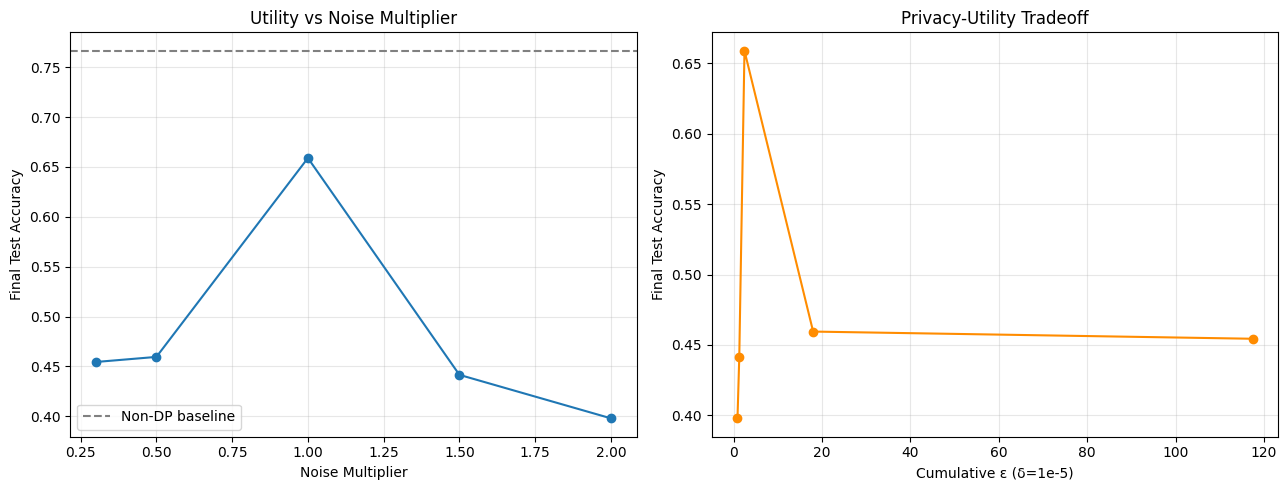

In [31]:
# ============================================================
# CELL — Save full sweep + plot utility-vs-privacy curve
# ============================================================
with open("/kaggle/working/phase5_sweep_results.json", "w") as f:
    json.dump({str(k): v for k, v in sweep_results.items()}, f, indent=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy vs noise_multiplier
noises = [sweep_results[nm]["noise_multiplier"] for nm in NOISE_SWEEP]
accs = [sweep_results[nm]["final_test_acc"] for nm in NOISE_SWEEP]
epsilons = [sweep_results[nm]["final_avg_epsilon"] for nm in NOISE_SWEEP]

axes[0].plot(noises, accs, marker='o')
axes[0].axhline(y=iid_results["final_test_acc"], color='gray', linestyle='--', label="Non-DP baseline")
axes[0].set_xlabel("Noise Multiplier")
axes[0].set_ylabel("Final Test Accuracy")
axes[0].set_title("Utility vs Noise Multiplier")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy vs epsilon (the classic privacy-utility tradeoff curve)
axes[1].plot(epsilons, accs, marker='o', color='darkorange')
axes[1].set_xlabel("Cumulative ε (δ=1e-5)")
axes[1].set_ylabel("Final Test Accuracy")
axes[1].set_title("Privacy-Utility Tradeoff")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/phase5_privacy_utility_tradeoff.png", dpi=120)
plt.show()

In [32]:
# ============================================================
# CELL — Extend the sweep with higher-noise (meaningfully private) settings
# ============================================================
EXTRA_NOISE_SWEEP = [3.0, 5.0]

for nm in EXTRA_NOISE_SWEEP:
    print(f"=== noise_multiplier={nm} ===")
    sweep_results[nm] = run_dp_fl_experiment(noise_multiplier=nm)
    print(f"  -> Final acc: {sweep_results[nm]['final_test_acc']:.4f} | "
          f"Final ε: {sweep_results[nm]['final_avg_epsilon']:.3f} | "
          f"Time: {sweep_results[nm]['elapsed_sec']:.1f}s\n")

FULL_NOISE_SWEEP = NOISE_SWEEP + EXTRA_NOISE_SWEEP  # [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

=== noise_multiplier=3.0 ===


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


  Round  1/30 | Acc: 0.1008 | Cumulative avg ε: 0.097
  Round  2/30 | Acc: 0.1858 | Cumulative avg ε: 0.135
  Round  3/30 | Acc: 0.2211 | Cumulative avg ε: 0.165
  Round  4/30 | Acc: 0.2120 | Cumulative avg ε: 0.191
  Round  5/30 | Acc: 0.2290 | Cumulative avg ε: 0.214
  Round  6/30 | Acc: 0.2355 | Cumulative avg ε: 0.235
  Round  7/30 | Acc: 0.2380 | Cumulative avg ε: 0.254
  Round  8/30 | Acc: 0.2266 | Cumulative avg ε: 0.272
  Round  9/30 | Acc: 0.2493 | Cumulative avg ε: 0.289
  Round 10/30 | Acc: 0.2279 | Cumulative avg ε: 0.306
  Round 11/30 | Acc: 0.2251 | Cumulative avg ε: 0.321
  Round 12/30 | Acc: 0.2431 | Cumulative avg ε: 0.336
  Round 13/30 | Acc: 0.2354 | Cumulative avg ε: 0.350
  Round 14/30 | Acc: 0.2487 | Cumulative avg ε: 0.364
  Round 15/30 | Acc: 0.2261 | Cumulative avg ε: 0.378
  Round 16/30 | Acc: 0.2501 | Cumulative avg ε: 0.391
  Round 17/30 | Acc: 0.2437 | Cumulative avg ε: 0.403
  Round 18/30 | Acc: 0.2066 | Cumulative avg ε: 0.416
  Round 19/30 | Acc: 0.2369 

In [33]:
# ============================================================
# CELL — Rebuild the table and plots with the extended sweep
# ============================================================
table_rows = [{
    "Experiment": "Baseline",
    "Clients": NUM_CLIENTS,
    "IID/Non-IID": "IID",
    "DP": "No",
    "Noise Multiplier": 0,
    "Clip Norm": "-",
    "epsilon": "-",
    "Accuracy": iid_results["final_test_acc"],
}]

for i, nm in enumerate(FULL_NOISE_SWEEP, start=1):
    r = sweep_results[nm]
    table_rows.append({
        "Experiment": f"DP-{i}",
        "Clients": NUM_CLIENTS,
        "IID/Non-IID": "IID",
        "DP": "Yes",
        "Noise Multiplier": r["noise_multiplier"],
        "Clip Norm": r["max_grad_norm"],
        "epsilon": round(r["final_avg_epsilon"], 3),
        "Accuracy": round(r["final_test_acc"], 4),
    })

results_table = pd.DataFrame(table_rows)
print(results_table.to_string(index=False))
results_table.to_csv("/kaggle/working/phase5_privacy_sweep_table_extended.csv", index=False)

Experiment  Clients IID/Non-IID  DP  Noise Multiplier Clip Norm epsilon  Accuracy
  Baseline        5         IID  No               0.0         -       -    0.7665
      DP-1        5         IID Yes               0.3       1.0  117.42    0.4544
      DP-2        5         IID Yes               0.5       1.0  17.994    0.4595
      DP-3        5         IID Yes               1.0       1.0    2.46    0.6589
      DP-4        5         IID Yes               1.5       1.0   1.284    0.4415
      DP-5        5         IID Yes               2.0       1.0   0.881    0.3979
      DP-6        5         IID Yes               3.0       1.0   0.544    0.2221
      DP-7        5         IID Yes               5.0       1.0   0.309    0.1008


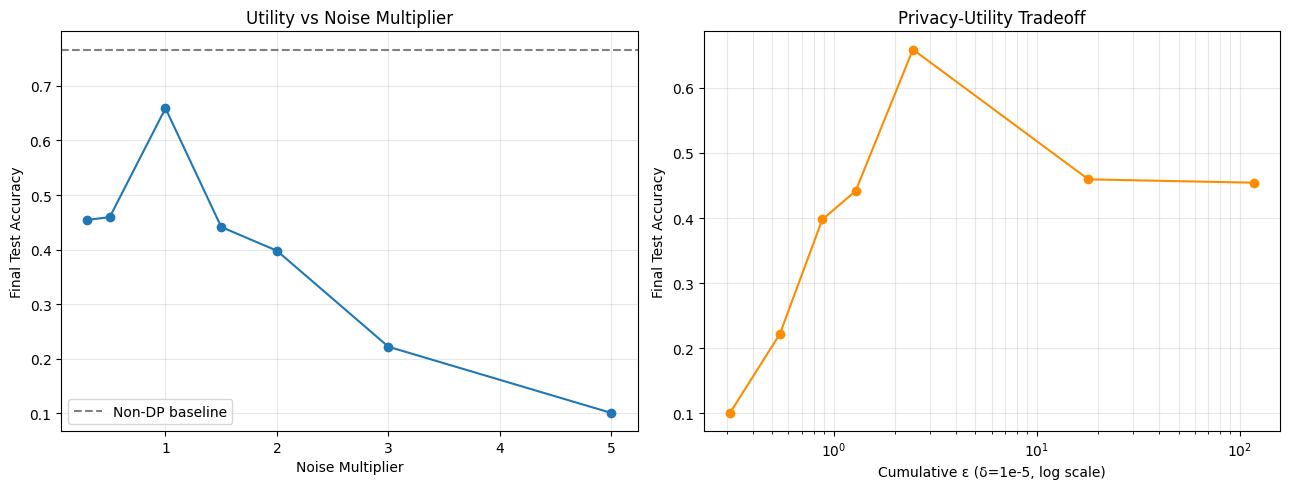

In [34]:
# ============================================================
# CELL — Re-plot with extended sweep, log-scale epsilon axis
# (117 vs ~1 on a linear axis crushes the informative low-epsilon region —
#  log scale is standard practice for epsilon axes in DP literature for
#  exactly this reason)
# ============================================================
noises = [sweep_results[nm]["noise_multiplier"] for nm in FULL_NOISE_SWEEP]
accs = [sweep_results[nm]["final_test_acc"] for nm in FULL_NOISE_SWEEP]
epsilons = [sweep_results[nm]["final_avg_epsilon"] for nm in FULL_NOISE_SWEEP]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(noises, accs, marker='o')
axes[0].axhline(y=iid_results["final_test_acc"], color='gray', linestyle='--', label="Non-DP baseline")
axes[0].set_xlabel("Noise Multiplier")
axes[0].set_ylabel("Final Test Accuracy")
axes[0].set_title("Utility vs Noise Multiplier")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epsilons, accs, marker='o', color='darkorange')
axes[1].set_xscale('log')
axes[1].set_xlabel("Cumulative ε (δ=1e-5, log scale)")
axes[1].set_ylabel("Final Test Accuracy")
axes[1].set_title("Privacy-Utility Tradeoff")
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig("/kaggle/working/phase5_privacy_utility_tradeoff_extended.png", dpi=120)
plt.show()

# Phase 6 — Reconstruction Attack (FL without DP)

The attack method: Deep Leakage from Gradients (DLG), Zhu, Liu & Han, NeurIPS 2019 (arXiv:1906.08935) — the foundational gradient-inversion attack and the natural first attack to implement

In [35]:
# ============================================================
# CELL 1 — Setup: load the trained non-DP global model (Phase 2 result)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import json

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load the model architecture (non-inplace version, for consistency with later
# phases — doesn't affect the attack itself either way)
attack_model = SimpleCNN().to(device)
attack_model.load_state_dict(torch.load("/kaggle/working/fl_iid_global_model.pt", map_location=device))
attack_model.eval()  # DLG attacks typically use eval mode to avoid dropout randomness

print("Loaded trained non-DP FL global model for attack target.")

Loaded trained non-DP FL global model for attack target.


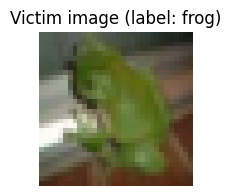

In [36]:
# ============================================================
# CELL 2 — Pick a real victim image + label from CIFAR-10 test set
# ============================================================
CIFAR10_MEAN = torch.tensor((0.4914, 0.4822, 0.4465)).view(1, 3, 1, 1).to(device)
CIFAR10_STD  = torch.tensor((0.2470, 0.2435, 0.2616)).view(1, 3, 1, 1).to(device)

victim_idx = 7  # arbitrary fixed choice for reproducibility
victim_image, victim_label = test_set[victim_idx]
victim_image = victim_image.unsqueeze(0).to(device)          # [1, 3, 32, 32], already normalized
victim_label = torch.tensor([victim_label]).to(device)

def denormalize(img_tensor):
    return (img_tensor * CIFAR10_STD + CIFAR10_MEAN).clamp(0, 1)

plt.figure(figsize=(2, 2))
plt.imshow(denormalize(victim_image)[0].permute(1, 2, 0).cpu().numpy())
plt.title(f"Victim image (label: {classes[victim_label.item()]})")
plt.axis("off")
plt.savefig("/kaggle/working/attack_victim_image.png", dpi=120)
plt.show()

In [37]:
# ============================================================
# CELL 3 — Core DLG reconstruction algorithm (shared by both experiments)
# Method: Zhu, Liu & Han, "Deep Leakage from Gradients", NeurIPS 2019
# (arXiv:1906.08935)
# ============================================================
def compute_gradient(model, images, labels, criterion):
    """Computes the gradient of the loss w.r.t. model parameters for a
    given batch — this is what the attacker is assumed to observe."""
    model.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    grads = torch.autograd.grad(loss, model.parameters())
    return [g.detach().clone() for g in grads]


def dlg_attack(model, target_gradient, image_shape, num_classes=10,
               num_iterations=300, lr=0.1, seed=0, log_every=50):
    """
    Reconstructs an input image (and its soft label) by optimizing a
    "dummy" image + label so that the gradient THEY produce matches the
    observed target_gradient as closely as possible (L2 distance).

    This is the original DLG formulation (Zhu et al. 2019): both the image
    AND the one-hot label are treated as continuous optimization variables.
    """
    torch.manual_seed(seed)
    criterion = nn.CrossEntropyLoss()

    dummy_image = torch.randn(image_shape, device=device, requires_grad=True)
    dummy_label_logits = torch.randn(1, num_classes, device=device, requires_grad=True)

    optimizer = torch.optim.LBFGS([dummy_image, dummy_label_logits], lr=lr)

    history = {"iteration": [], "grad_diff": []}

    for it in range(num_iterations):
        def closure():
            optimizer.zero_grad()
            dummy_label_soft = F.softmax(dummy_label_logits, dim=-1)
            dummy_pred = model(dummy_image)
            dummy_loss = -torch.sum(dummy_label_soft * F.log_softmax(dummy_pred, dim=-1))
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

            grad_diff = sum(
                ((dg - tg) ** 2).sum() for dg, tg in zip(dummy_grads, target_gradient)
            )
            grad_diff.backward()
            return grad_diff

        grad_diff_value = optimizer.step(closure)

        if it % log_every == 0 or it == num_iterations - 1:
            history["iteration"].append(it)
            history["grad_diff"].append(grad_diff_value.item())
            print(f"  Iter {it:4d} | Gradient matching loss: {grad_diff_value.item():.6f}")

    return dummy_image.detach(), dummy_label_logits.detach(), history

In [38]:
# ============================================================
# EXPERIMENT A — Standard single-step DLG (1 image, 1 gradient step)
# ============================================================
print("=== Experiment A: Single-step DLG attack ===")

criterion = nn.CrossEntropyLoss()
target_grad_single = compute_gradient(attack_model, victim_image, victim_label, criterion)

recon_image_A, recon_label_logits_A, history_A = dlg_attack(
    attack_model, target_grad_single, image_shape=victim_image.shape,
    num_iterations=300, lr=0.1, seed=0
)

recon_label_A = recon_label_logits_A.argmax(dim=-1).item()
print(f"\nTrue label: {classes[victim_label.item()]} | Reconstructed label guess: {classes[recon_label_A]}")

=== Experiment A: Single-step DLG attack ===
  Iter    0 | Gradient matching loss: 25032.816406
  Iter   50 | Gradient matching loss: 3275.260986
  Iter  100 | Gradient matching loss: 3275.260986
  Iter  150 | Gradient matching loss: 3275.260986
  Iter  200 | Gradient matching loss: 3275.260986
  Iter  250 | Gradient matching loss: 3275.260986
  Iter  299 | Gradient matching loss: 3275.260986

True label: frog | Reconstructed label guess: frog


In [39]:
# ============================================================
# CELL — Reconstruction quality metrics (MSE, PSNR, SSIM)
# ============================================================
!pip install -q scikit-image
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def evaluate_reconstruction(true_img, recon_img):
    """
    true_img, recon_img: normalized tensors [1, 3, 32, 32] on same device.
    Denormalizes to [0,1] pixel space before computing metrics, since MSE/
    PSNR/SSIM should be evaluated in a meaningful pixel-value range.
    """
    true_np = denormalize(true_img)[0].permute(1, 2, 0).cpu().numpy()
    recon_np = denormalize(recon_img)[0].permute(1, 2, 0).detach().cpu().numpy()
    recon_np = np.clip(recon_np, 0, 1)

    mse = np.mean((true_np - recon_np) ** 2)
    psnr_val = psnr(true_np, recon_np, data_range=1.0)
    ssim_val = ssim(true_np, recon_np, data_range=1.0, channel_axis=2)

    return {"MSE": float(mse), "PSNR": float(psnr_val), "SSIM": float(ssim_val)}

metrics_A = evaluate_reconstruction(victim_image, recon_image_A)
print("Experiment A reconstruction metrics:", metrics_A)

Experiment A reconstruction metrics: {'MSE': 0.2709226906299591, 'PSNR': 5.671546416925841, 'SSIM': 0.005541922524571419}


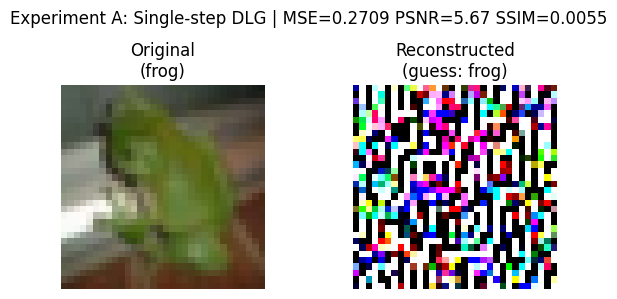

In [40]:
# ============================================================
# CELL — Visual comparison: original vs reconstructed (Experiment A)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(denormalize(victim_image)[0].permute(1, 2, 0).cpu().numpy())
axes[0].set_title(f"Original\n({classes[victim_label.item()]})")
axes[0].axis("off")

axes[1].imshow(np.clip(denormalize(recon_image_A)[0].permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
axes[1].set_title(f"Reconstructed\n(guess: {classes[recon_label_A]})")
axes[1].axis("off")

plt.suptitle(f"Experiment A: Single-step DLG | MSE={metrics_A['MSE']:.4f} PSNR={metrics_A['PSNR']:.2f} SSIM={metrics_A['SSIM']:.4f}")
plt.tight_layout()
plt.savefig("/kaggle/working/attack_experimentA_comparison.png", dpi=120)
plt.show()

In [41]:
# ============================================================
# EXPERIMENT B — Attack against the REAL FL local update (full local epoch,
# multiple batches, matching your actual client training procedure)
# ============================================================
print("\n=== Experiment B: Full local-epoch update attack ===")

def compute_full_local_update_gradient(global_model, client_loader, lr=0.01, local_epochs=1):
    """
    Simulates exactly what a Phase 2-style client does: trains locally for
    a full epoch (possibly many batches), then returns the DIFFERENCE
    between the global weights and the resulting local weights — this
    difference is mathematically an aggregated pseudo-gradient over all
    local steps (this is what the server actually observes in FedAvg, as
    opposed to a single raw gradient).
    """
    model = SimpleCNN().to(device)
    model.load_state_dict(global_model.state_dict())
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(local_epochs):
        for images, labels in client_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    # Pseudo-gradient = (initial - final) / lr, an approximation standard
    # in FL attack literature for treating a multi-step update as a single
    # "gradient-like" object DLG can attack.
    pseudo_grad = [
        (p0.detach() - p1.detach()) / lr
        for p0, p1 in zip(global_model.parameters(), model.parameters())
    ]
    return pseudo_grad

# Use client 0's actual data loader from Phase 2/3 (IID split) as the "victim client"
target_grad_full = compute_full_local_update_gradient(
    attack_model, client_loaders[0], lr=0.01, local_epochs=1
)

recon_image_B, recon_label_logits_B, history_B = dlg_attack(
    attack_model, target_grad_full, image_shape=victim_image.shape,
    num_iterations=300, lr=0.1, seed=0
)

recon_label_B = recon_label_logits_B.argmax(dim=-1).item()
metrics_B = evaluate_reconstruction(victim_image, recon_image_B)
print(f"\nExperiment B reconstruction metrics (vs the SAME victim image, for a fair visual comparison — "
      f"note: client 0's real batch did NOT necessarily contain this exact image):", metrics_B)


=== Experiment B: Full local-epoch update attack ===
  Iter    0 | Gradient matching loss: 231819.093750
  Iter   50 | Gradient matching loss: 210809.437500
  Iter  100 | Gradient matching loss: 210809.437500
  Iter  150 | Gradient matching loss: 210809.437500
  Iter  200 | Gradient matching loss: 210809.437500
  Iter  250 | Gradient matching loss: 210809.437500
  Iter  299 | Gradient matching loss: 210809.437500

Experiment B reconstruction metrics (vs the SAME victim image, for a fair visual comparison — note: client 0's real batch did NOT necessarily contain this exact image): {'MSE': 0.2705255448818207, 'PSNR': 5.677917018673691, 'SSIM': 0.005380855407565832}


In [42]:
# ============================================================
# EXPERIMENT B — Single BATCH, single gradient step (well-posed middle ground)
# The "victim" here is a real batch from client 0's actual data —
# multiple images, but exactly one gradient step, so the batch itself is
# a well-defined target (unlike a full epoch).
# ============================================================
print("=== Experiment B: Single-batch DLG attack ===")

# Grab one real batch from client 0's loader (same client used in Phase 2/3)
victim_batch_images, victim_batch_labels = next(iter(client_loaders[0]))
victim_batch_images = victim_batch_images.to(device)
victim_batch_labels = victim_batch_labels.to(device)
batch_size_B = victim_batch_images.shape[0]

print(f"Victim batch size: {batch_size_B}")

target_grad_batch = compute_gradient(attack_model, victim_batch_images, victim_batch_labels, criterion)

# NOTE: reconstructing a whole batch means recovering batch_size_B images
# simultaneously from ONE observed gradient — the optimization variable
# needs to match that shape, not a single image.
dummy_batch_shape = victim_batch_images.shape  # [batch_size_B, 3, 32, 32]

def dlg_attack_batch(model, target_gradient, batch_shape, num_classes=10,
                      num_iterations=300, lr=0.1, seed=0, log_every=50):
    """Same DLG algorithm as dlg_attack, generalized to a batch of images
    and a batch of (soft) labels instead of a single image/label."""
    torch.manual_seed(seed)
    batch_n = batch_shape[0]

    dummy_images = torch.randn(batch_shape, device=device, requires_grad=True)
    dummy_label_logits = torch.randn(batch_n, num_classes, device=device, requires_grad=True)

    optimizer = torch.optim.LBFGS([dummy_images, dummy_label_logits], lr=lr)
    history = {"iteration": [], "grad_diff": []}

    for it in range(num_iterations):
        def closure():
            optimizer.zero_grad()
            dummy_label_soft = F.softmax(dummy_label_logits, dim=-1)
            dummy_pred = model(dummy_images)
            # Mean CE loss over the batch, matching how the real client loss was computed
            dummy_loss = -torch.mean(torch.sum(dummy_label_soft * F.log_softmax(dummy_pred, dim=-1), dim=-1))
            dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            grad_diff = sum(((dg - tg) ** 2).sum() for dg, tg in zip(dummy_grads, target_gradient))
            grad_diff.backward()
            return grad_diff

        grad_diff_value = optimizer.step(closure)
        if it % log_every == 0 or it == num_iterations - 1:
            history["iteration"].append(it)
            history["grad_diff"].append(grad_diff_value.item())
            print(f"  Iter {it:4d} | Gradient matching loss: {grad_diff_value.item():.6f}")

    return dummy_images.detach(), dummy_label_logits.detach(), history


recon_batch_B, recon_label_logits_B, history_B = dlg_attack_batch(
    attack_model, target_grad_batch, dummy_batch_shape,
    num_iterations=300, lr=0.1, seed=0
)

=== Experiment B: Single-batch DLG attack ===
Victim batch size: 64
  Iter    0 | Gradient matching loss: 14210.693359
  Iter   50 | Gradient matching loss: 324859363328.000000
  Iter  100 | Gradient matching loss: 23148505543448863260540928.000000
  Iter  150 | Gradient matching loss: 1154645482544204401868800.000000
  Iter  200 | Gradient matching loss: 195139764889263456387072.000000
  Iter  250 | Gradient matching loss: 1022314129346405660266332160.000000
  Iter  299 | Gradient matching loss: 6993690173685182776595185664.000000


Experiment B — mean reconstruction metrics across batch: {'MSE': 0.30950060952454805, 'PSNR': 5.110563462256959, 'SSIM': 0.0031955468261912756}


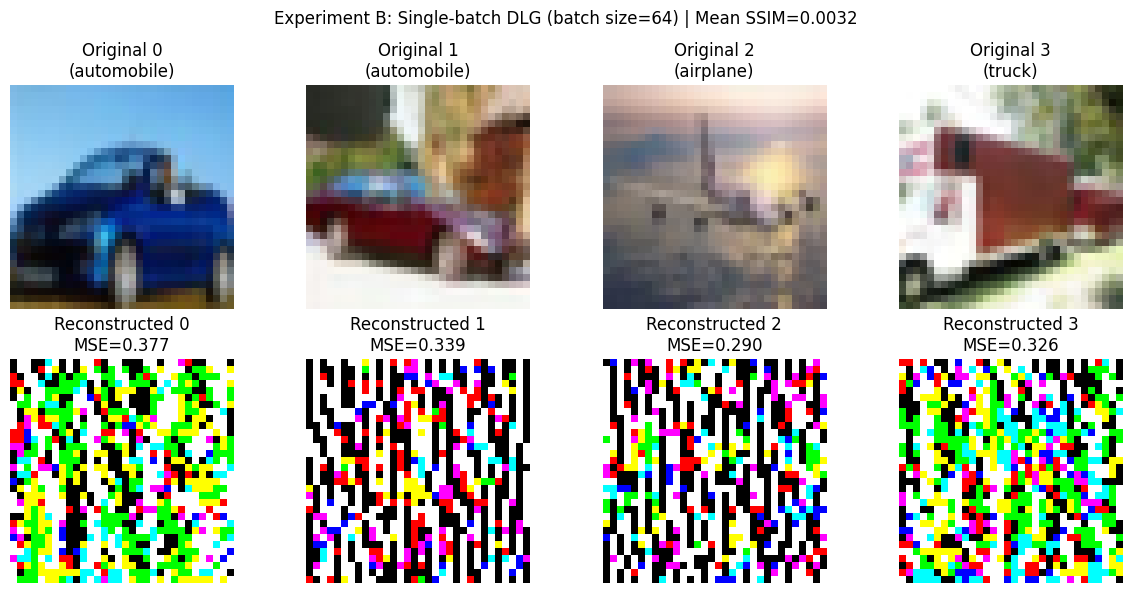

In [43]:
# ============================================================
# CELL — Evaluate & visualize Experiment B (per-image metrics across the batch)
# ============================================================
def evaluate_reconstruction_batch(true_batch, recon_batch):
    """Per-image MSE/PSNR/SSIM across a batch, plus the mean."""
    results = []
    for i in range(true_batch.shape[0]):
        m = evaluate_reconstruction(true_batch[i:i+1], recon_batch[i:i+1])
        results.append(m)
    mean_metrics = {k: float(np.mean([r[k] for r in results])) for k in results[0]}
    return results, mean_metrics

per_image_metrics_B, mean_metrics_B = evaluate_reconstruction_batch(victim_batch_images, recon_batch_B)
print("Experiment B — mean reconstruction metrics across batch:", mean_metrics_B)

# Show first 4 images of the batch: original vs reconstructed
n_show = min(4, batch_size_B)
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(denormalize(victim_batch_images[i:i+1])[0].permute(1, 2, 0).cpu().numpy())
    axes[0, i].set_title(f"Original {i}\n({classes[victim_batch_labels[i].item()]})")
    axes[0, i].axis("off")

    recon_np = np.clip(denormalize(recon_batch_B[i:i+1])[0].permute(1, 2, 0).detach().cpu().numpy(), 0, 1)
    axes[1, i].imshow(recon_np)
    axes[1, i].set_title(f"Reconstructed {i}\nMSE={per_image_metrics_B[i]['MSE']:.3f}")
    axes[1, i].axis("off")

plt.suptitle(f"Experiment B: Single-batch DLG (batch size={batch_size_B}) | Mean SSIM={mean_metrics_B['SSIM']:.4f}")
plt.tight_layout()
plt.savefig("/kaggle/working/attack_experimentB_comparison.png", dpi=120)
plt.show()

In [44]:
# ============================================================
# EXPERIMENT C — Full local epoch (many batches) — the ACTUAL FL update
# Renamed from your earlier "Experiment B" — same idea, honest caveat kept
# ============================================================
print("\n=== Experiment C: Full local-epoch pseudo-gradient attack ===")

def compute_full_local_update_gradient(global_model, client_loader, lr=0.01, local_epochs=1):
    model = SimpleCNN().to(device)
    model.load_state_dict(global_model.state_dict())
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    for epoch in range(local_epochs):
        for images, labels in client_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = crit(model(images), labels)
            loss.backward()
            optimizer.step()
    pseudo_grad = [
        (p0.detach() - p1.detach()) / lr
        for p0, p1 in zip(global_model.parameters(), model.parameters())
    ]
    return pseudo_grad

target_grad_full = compute_full_local_update_gradient(attack_model, client_loaders[0], lr=0.01, local_epochs=1)

# Attack shape matches ONE representative image (we can only ask "does anything
# image-like emerge", not "recover THE image" — there isn't one)
recon_image_C, recon_label_logits_C, history_C = dlg_attack(
    attack_model, target_grad_full, image_shape=victim_image.shape,
    num_iterations=300, lr=0.1, seed=0
)

metrics_C_vs_victim = evaluate_reconstruction(victim_image, recon_image_C)
print("Experiment C metrics (vs an arbitrary reference image — NOT a valid reconstruction target, see caveat below):",
      metrics_C_vs_victim)


=== Experiment C: Full local-epoch pseudo-gradient attack ===
  Iter    0 | Gradient matching loss: 245517.468750
  Iter   50 | Gradient matching loss: 224182.984375
  Iter  100 | Gradient matching loss: 224182.984375
  Iter  150 | Gradient matching loss: 224182.984375
  Iter  200 | Gradient matching loss: 224182.984375
  Iter  250 | Gradient matching loss: 224182.984375
  Iter  299 | Gradient matching loss: 224182.984375
Experiment C metrics (vs an arbitrary reference image — NOT a valid reconstruction target, see caveat below): {'MSE': 0.27000465989112854, 'PSNR': 5.686287355030888, 'SSIM': 0.004962953273206949}
